# Steel Energy Hub — Veri Keşfi
Bu notebook, `main_data.energy_readings` tablosundaki verinin istatistiksel analizini yapar.
Anomali tespiti ve Kafka producer için zemin hazırlar.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import psycopg2
import warnings
warnings.filterwarnings('ignore')

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


In [2]:
# --- Veritabanı bağlantısı ---
conn = psycopg2.connect(
    host='timescaledb',
    port=5432,
    database='energydb',
    user='data_writer',
    password='sifre123',
    options='-c search_path=main_data'
)

df = pd.read_sql("""
    SELECT *
    FROM main_data.energy_readings
    ORDER BY time
""", conn)

conn.close()
print(f'Yüklenen satır sayısı: {len(df)}')
df.head()

Yüklenen satır sayısı: 35040


,time,usage_kwh,lagging_reactive_power,leading_reactive_power,co2_tco2,lagging_pf,leading_pf,nsm,week_status,day_of_week,load_type
0,2018-01-01 00:00:00+00:00,3.42,3.46,0.0,0.0,70.30,100.0,0,Weekday,Monday,Light_Load
1,2018-01-01 00:15:00+00:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
2,2018-01-01 00:30:00+00:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
3,2018-01-01 00:45:00+00:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
4,2018-01-01 01:00:00+00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load


## 1. Genel Bakış

In [3]:
print('=== GENEL BİLGİ ===')
print(f'Satır sayısı  : {len(df)}')
print(f'Kolon sayısı  : {len(df.columns)}')
print(f'Tarih aralığı : {df["time"].min()} → {df["time"].max()}')
print(f'Null değerler :\n{df.isnull().sum()}')
print()
print('=== VERİ TİPLERİ ===')
print(df.dtypes)

=== GENEL BİLGİ ===
Satır sayısı  : 35040
Kolon sayısı  : 11
Tarih aralığı : 2018-01-01 00:00:00+00:00 → 2018-12-31 23:45:00+00:00
Null değerler :
time                      0
usage_kwh                 0
lagging_reactive_power    0
leading_reactive_power    0
co2_tco2                  0
lagging_pf                0
leading_pf                0
nsm                       0
week_status               0
day_of_week               0
load_type                 0
dtype: int64

=== VERİ TİPLERİ ===
time                      datetime64[ns, UTC]
usage_kwh                             float64
lagging_reactive_power                float64
leading_reactive_power                float64
co2_tco2                              float64
lagging_pf                            float64
leading_pf                            float64
nsm                                     int64
week_status                            object
day_of_week                            object
load_type                              object
dtyp

In [4]:
print('=== İSTATİSTİKSEL ÖZET ===')
df.describe().round(2)

=== İSTATİSTİKSEL ÖZET ===


,usage_kwh,lagging_reactive_power,leading_reactive_power,co2_tco2,lagging_pf,leading_pf,nsm
count,35040.00,35040.00,35040.00,35040.00,35040.00,35040.00,35040.00
mean,27.39,13.04,3.87,0.01,80.58,84.37,42750.00
std,33.44,16.31,7.42,0.02,18.92,30.46,24940.53
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,3.20,2.30,0.00,0.00,63.32,99.70,21375.00
50%,4.57,5.00,0.00,0.00,87.96,100.00,42750.00
75%,51.24,22.64,2.09,0.02,99.02,100.00,64125.00
max,157.18,96.91,27.76,0.07,100.00,100.00,85500.00


## 2. Load Type Dağılımı

Load Type dağılımı:
load_type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64

Yüzdelik dağılım:
load_type
Light_Load      51.58
Medium_Load     27.67
Maximum_Load    20.75
Name: count, dtype: float64


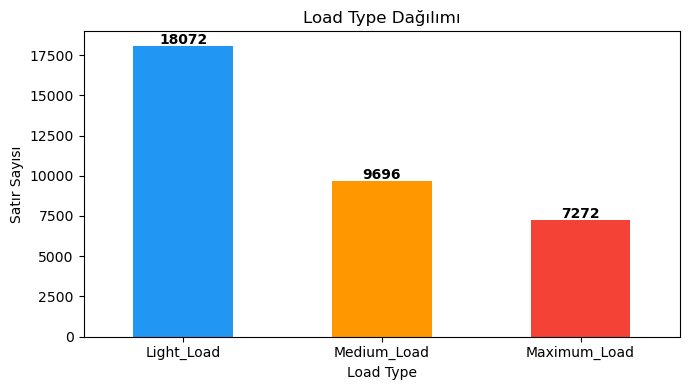

In [5]:
load_dist = df['load_type'].value_counts()
print('Load Type dağılımı:')
print(load_dist)
print()
print('Yüzdelik dağılım:')
print((load_dist / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(7, 4))
load_dist.plot(kind='bar', ax=ax, color=['#2196F3', '#FF9800', '#F44336'])
ax.set_title('Load Type Dağılımı')
ax.set_xlabel('Load Type')
ax.set_ylabel('Satır Sayısı')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(load_dist):
    ax.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Usage_kWh Dağılımı ve Aykırı Değerler

Usage_kWh istatistikleri:
  Ortalama : 27.39
  Std      : 33.44
  Min      : 0.00
  Max      : 157.18
  IQR alt  : -68.86
  IQR üst  : 123.29
  Aykırı değer sayısı: 328 (0.94%)


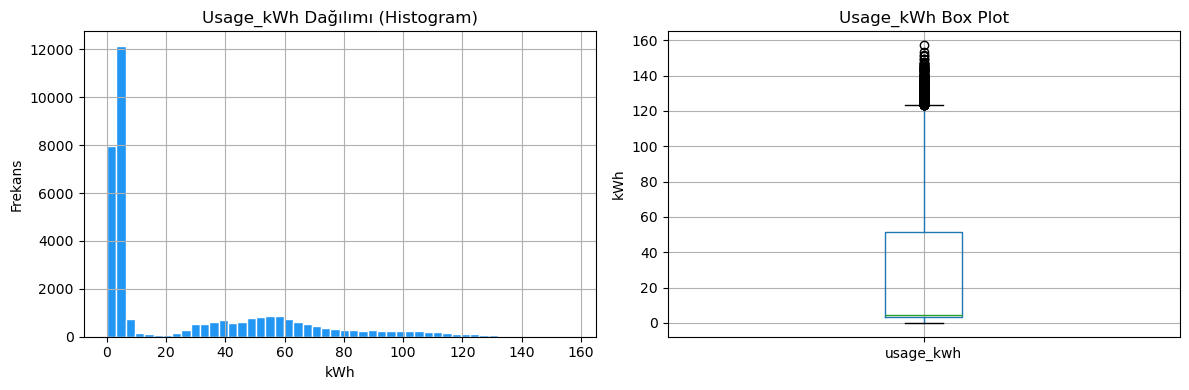

In [6]:
Q1 = df['usage_kwh'].quantile(0.25)
Q3 = df['usage_kwh'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['usage_kwh'] < lower) | (df['usage_kwh'] > upper)]

print(f'Usage_kWh istatistikleri:')
print(f'  Ortalama : {df["usage_kwh"].mean():.2f}')
print(f'  Std      : {df["usage_kwh"].std():.2f}')
print(f'  Min      : {df["usage_kwh"].min():.2f}')
print(f'  Max      : {df["usage_kwh"].max():.2f}')
print(f'  IQR alt  : {lower:.2f}')
print(f'  IQR üst  : {upper:.2f}')
print(f'  Aykırı değer sayısı: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['usage_kwh'].hist(bins=50, ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('Usage_kWh Dağılımı (Histogram)')
axes[0].set_xlabel('kWh')
axes[0].set_ylabel('Frekans')

df.boxplot(column='usage_kwh', ax=axes[1])
axes[1].set_title('Usage_kWh Box Plot')
axes[1].set_ylabel('kWh')

plt.tight_layout()
plt.show()

## 4. Saatlik Ortalama Tüketim (Pik Saatler)

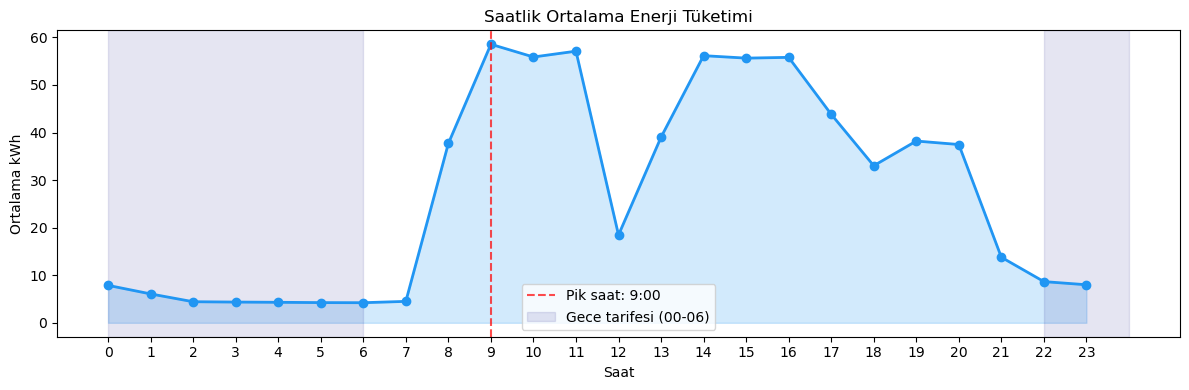

En yüksek tüketim saati: 9:00 (58.55 kWh)
En düşük tüketim saati: 6:00 (4.22 kWh)


In [7]:
df['hour'] = pd.to_datetime(df['time']).dt.hour
hourly_avg = df.groupby('hour')['usage_kwh'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_avg.index, hourly_avg.values, marker='o', color='#2196F3', linewidth=2)
ax.fill_between(hourly_avg.index, hourly_avg.values, alpha=0.2, color='#2196F3')

# Pik saati işaretle
peak_hour = hourly_avg.idxmax()
ax.axvline(x=peak_hour, color='red', linestyle='--', alpha=0.7, label=f'Pik saat: {peak_hour}:00')

# Gece tarifesi (22:00-06:00) bölgesi
ax.axvspan(0, 6, alpha=0.1, color='navy', label='Gece tarifesi (00-06)')
ax.axvspan(22, 24, alpha=0.1, color='navy')

ax.set_title('Saatlik Ortalama Enerji Tüketimi')
ax.set_xlabel('Saat')
ax.set_ylabel('Ortalama kWh')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

print(f'En yüksek tüketim saati: {peak_hour}:00 ({hourly_avg[peak_hour]:.2f} kWh)')
print(f'En düşük tüketim saati: {hourly_avg.idxmin()}:00 ({hourly_avg.min():.2f} kWh)')

## 5. Haftalık Tüketim Karşılaştırması

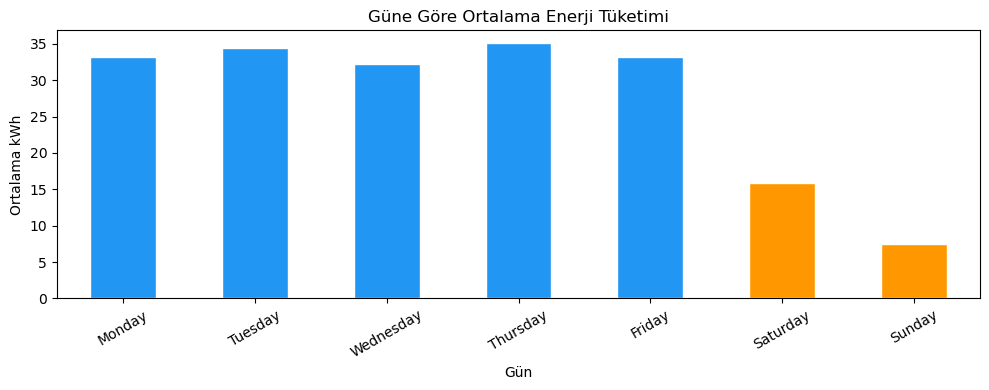

Hafta içi vs Hafta sonu:
              mean    std   min     max
week_status                            
Weekday      33.62  35.62  0.00  157.18
Weekend      11.73  19.95  2.45  133.42


In [8]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_avg = df.groupby('day_of_week')['usage_kwh'].mean().reindex(day_order)

colors = ['#2196F3'] * 5 + ['#FF9800'] * 2  # Hafta içi mavi, hafta sonu turuncu

fig, ax = plt.subplots(figsize=(10, 4))
day_avg.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Güne Göre Ortalama Enerji Tüketimi')
ax.set_xlabel('Gün')
ax.set_ylabel('Ortalama kWh')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('Hafta içi vs Hafta sonu:')
print(df.groupby('week_status')['usage_kwh'].agg(['mean', 'std', 'min', 'max']).round(2))

## 6. Zaman Serisi — Tüm Yıl

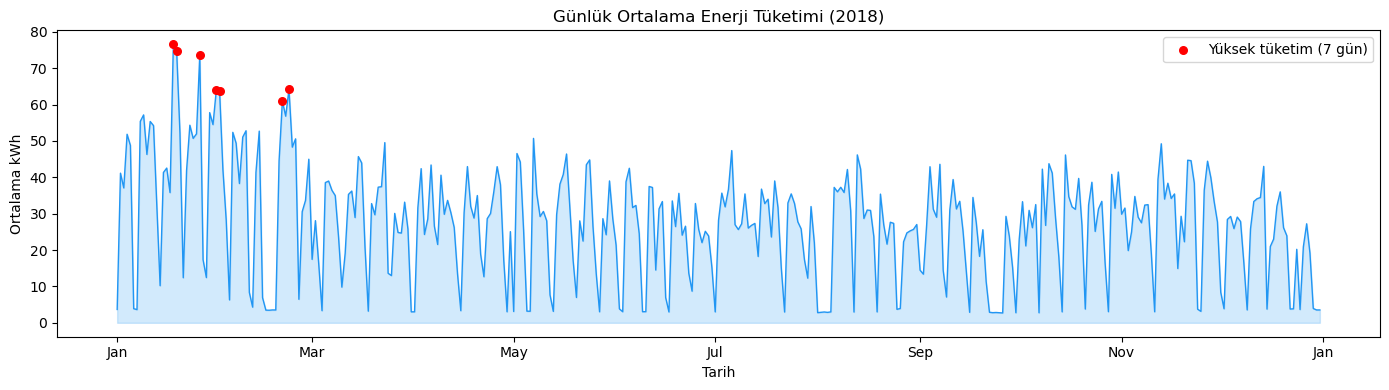

Yüksek tüketimli günler (2σ üstü): 7
time
2018-01-18 00:00:00+00:00    76.602500
2018-01-19 00:00:00+00:00    74.740625
2018-01-26 00:00:00+00:00    73.638437
2018-02-22 00:00:00+00:00    64.179167
2018-01-31 00:00:00+00:00    63.973333
2018-02-01 00:00:00+00:00    63.694375
2018-02-20 00:00:00+00:00    60.975104
Name: usage_kwh, dtype: float64


In [9]:
df_daily = df.set_index('time').resample('D')['usage_kwh'].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_daily.index, df_daily.values, color='#2196F3', linewidth=1)
ax.fill_between(df_daily.index, df_daily.values, alpha=0.2, color='#2196F3')

# Aykırı günleri işaretle
mean = df_daily.mean()
std = df_daily.std()
anomaly_days = df_daily[df_daily > mean + 2*std]
ax.scatter(anomaly_days.index, anomaly_days.values, color='red', zorder=5, s=30, label=f'Yüksek tüketim ({len(anomaly_days)} gün)')

ax.set_title('Günlük Ortalama Enerji Tüketimi (2018)')
ax.set_xlabel('Tarih')
ax.set_ylabel('Ortalama kWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend()
plt.tight_layout()
plt.show()

print(f'Yüksek tüketimli günler (2σ üstü): {len(anomaly_days)}')
print(anomaly_days.sort_values(ascending=False).head(10))

## 7. Anomali Tespiti İçin Özet

In [10]:
mean = df['usage_kwh'].mean()
std = df['usage_kwh'].std()

df['z_score'] = (df['usage_kwh'] - mean) / std
df['anomaly'] = df['z_score'].abs() > 3

print('=== ANOMALİ ÖZET (Z-Score > 3) ===')
print(f'Toplam satır    : {len(df)}')
print(f'Anomali sayısı  : {df["anomaly"].sum()}')
print(f'Anomali oranı   : %{df["anomaly"].mean()*100:.3f}')
print()
print('Anomali örnekleri:')
df[df['anomaly']][['time', 'usage_kwh', 'z_score', 'load_type']].head(10)

=== ANOMALİ ÖZET (Z-Score > 3) ===
Toplam satır    : 35040
Anomali sayısı  : 212
Anomali oranı   : %0.605

Anomali örnekleri:


,time,usage_kwh,z_score,load_type
141,2018-01-02 11:15:00+00:00,128.52,3.023919,Maximum_Load
142,2018-01-02 11:30:00+00:00,144.47,3.500831,Maximum_Load
154,2018-01-02 14:30:00+00:00,129.10,3.041262,Medium_Load
156,2018-01-02 15:00:00+00:00,143.89,3.483488,Medium_Load
158,2018-01-02 15:30:00+00:00,141.44,3.410232,Medium_Load
160,2018-01-02 16:00:00+00:00,129.31,3.047541,Medium_Load
161,2018-01-02 16:15:00+00:00,136.44,3.260730,Medium_Load
163,2018-01-02 16:45:00+00:00,147.46,3.590233,Medium_Load
261,2018-01-03 17:15:00+00:00,140.51,3.382425,Maximum_Load
322,2018-01-04 08:30:00+00:00,136.19,3.253255,Light_Load
